In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [ ]:


# Define the stock ticker and the date range
ticker = 'AAPL'
start = '2010-01-01'
end = '2023-12-31'

# Fetch data using yfinance
df = yf.download(ticker, start=start, end=end)

# Display the first few rows of the data
print(df.head())


/tmp/ipykernel_4363/1648460319.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL
Date                                                         
2010-01-04  6.412385  6.427067  6.363545  6.395006  493729600
2010-01-05  6.423469  6.459724  6.389610  6.430061  601904800
2010-01-06  6.321295  6.448938  6.314703  6.423469  552160000
2010-01-07  6.309609  6.352157  6.263766  6.344666  477131200
2010-01-08  6.351558  6.352157  6.264067  6.301220  447610800


In [ ]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-12-22,191.609482,193.400870,190.985954,193.173224,37149600
2023-12-26,191.065125,191.896484,190.847385,191.619364,28919300
2023-12-27,191.164078,191.510485,189.125261,190.510875,48087700
2023-12-28,191.589661,192.658558,191.183873,192.143900,34049900
2023-12-29,190.550461,192.401229,189.758683,191.906370,42672100


In [ ]:
df=df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.412385,6.427067,6.363545,6.395006,493729600
1,2010-01-05,6.423469,6.459724,6.389610,6.430061,601904800
2,2010-01-06,6.321295,6.448938,6.314703,6.423469,552160000
3,2010-01-07,6.309609,6.352157,6.263766,6.344666,477131200
4,2010-01-08,6.351558,6.352157,6.264067,6.301220,447610800


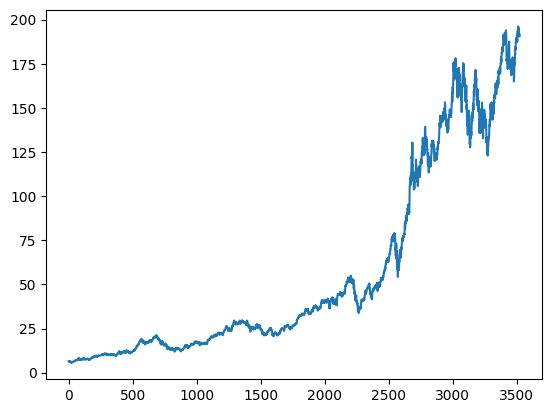

In [ ]:
plt.plot(df.Close)


In [ ]:
ma100=df.Close.rolling(100).mean()
ma100

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
3517    181.768301
3518    181.787101
3519    181.898701
3520    182.046001
3521    182.173301
Name: Close, Length: 3522, dtype: float64

In [ ]:
ma200=df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3517,176.443947
3518,176.667376
3519,176.881590
3520,177.087483


In [ ]:
df.shape


(3522, 6)

In [ ]:
#splitting data into training and testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

print(data_training.shape)
print(data_testing.shape)


(2465, 1)
(1057, 1)


In [ ]:
data_training.head()

Ticker,AAPL
0,6.412385
1,6.423469
2,6.321295
3,6.309609
4,6.351558


In [ ]:
data_testing.head()

Ticker,AAPL
2465,56.816948
2466,57.802319
2467,57.670139
2468,58.444000
2469,58.540142


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler(feature_range=(0,1))



In [ ]:
data_training_array=scaler.fit_transform(data_training)
data_training_array

array([[0.0128981 ],
       [0.01311536],
       [0.01111253],
       ...,
       [0.99580712],
       [0.99133151],
       [0.99561846]])

In [ ]:
x_train=[]
y_train=[]

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train , y_train = np.array(x_train), np.array(y_train)


In [ ]:
#ML MODEL

from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [ ]:
model = Sequential()
model.add(LSTM(units =50, activation='relu', return_sequences= True,
               input_shape= (x_train.shape[1],1)))
model.add(Dropout(0.2))


model.add(LSTM(units =60, activation='relu', return_sequences= True))
model.add(Dropout(0.3))


model.add(LSTM(units =80, activation='relu', return_sequences= True))
model.add(Dropout(0.4))


model.add(LSTM(units =120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units= 1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss= 'mean_squared_error')
model.fit(x_train, y_train, epochs=50)


Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 300ms/step - loss: 0.0252
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 298ms/step - loss: 0.0061
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 297ms/step - loss: 0.0070
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 275ms/step - loss: 0.0055
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 294ms/step - loss: 0.0045
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 293ms/step - loss: 0.0039
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 40s 285ms/step - loss: 0.0041
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 312ms/step - loss: 0.0043
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 40s 304ms/step - loss: 0.0040
Epoch 10/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 40s 284ms/step - loss: 0.0034
Epoch 11/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 284ms/step - loss: 0.0035
Epoch 12/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 42s 302ms/step - loss: 0.0037
Epoch 13/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 283ms/step - loss: 0.0030
Epoch 14/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 305ms/step - loss: 0.0032
Epoch 15/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 

In [ ]:
model.save('keras_model.h5')

In [ ]:
data_testing.head()

Ticker,AAPL
2465,56.816948
2466,57.802319
2467,57.670139
2468,58.444000
2469,58.540142


In [ ]:
past_100_days= data_training.tail(100)

In [ ]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [ ]:
final_df.head()

Ticker,AAPL
0,42.468781
1,42.689053
2,41.915710
3,41.491943
4,43.009884


In [ ]:
input_data=scaler.fit_transform(final_df)
input_data

array([[0.00631925],
       [0.00774421],
       [0.00274139],
       ...,
       [0.96824324],
       [0.97099637],
       [0.96427369]])

In [ ]:
input_data.shape

(1157, 1)

In [ ]:
x_test=[]
y_test=[]

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [ ]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(1057, 100, 1)
(1057,)


In [ ]:
#making predictions

y_predicted = model.predict(x_test)

34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step


In [ ]:
y_predicted.shape


(1057, 1)

In [ ]:
scaler.scale_ # gives the scale down factor

array([0.00646909])

In [ ]:
scale_factor =1/0.00646057
y_predicted= y_predicted* scale_factor
y_test= y_test*scale_factor

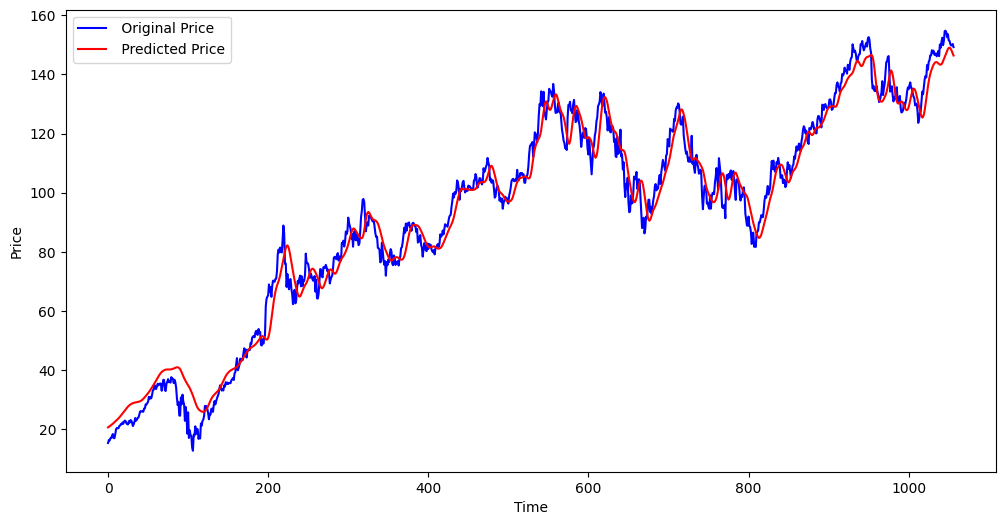

In [ ]:
plt.figure( figsize= (12,6))
plt.plot(y_test, 'b', label =' Original Price')
plt.plot(y_predicted, 'r', label =' Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# --- After y_predicted and y_test are inverse-scaled ---

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_predicted))
print(f"RMSE: ${rmse:.2f}")

# MAPE
mape = np.mean(np.abs((y_test - y_predicted) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")

# Directional Accuracy
actual_direction    = np.sign(np.diff(y_test))
predicted_direction = np.sign(np.diff(y_predicted.flatten()))
directional_acc = np.mean(actual_direction == predicted_direction) * 100
print(f"Directional Accuracy: {directional_acc:.2f}%")

RMSE: $5.51
MAPE: 70.45%
Directional Accuracy: 51.14%
